In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Preprocessing & pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [2]:
#Feature building for X 
import pandas as pd
import numpy as np

# 1. Chargement du dataset
data = pd.read_csv("Fraud_dataset.csv")

# 2. Initialisation de notre liste de features
features_selectionnees = []

# 3. Boucle d'analyse des colonnes
for col in data.columns:
    # On ignore la cible (le label à prédire) et les IDs
    if col in ["Fraud_Label", "Transaction_ID", "User_ID","Risk_Score"]:
        continue
    
    # Vérification : est-ce que la colonne est de type numérique ?
    if pd.api.types.is_numeric_dtype(data[col]):
        features_selectionnees.append(col)
        print(f"✅ Ajout de la feature numérique : {col}")
    else:
        print(f"❌ Colonne ignorée (non-numérique) : {col}")

# 4. Construction de X final
X = data[features_selectionnees]

print(f"\nDimensions finales de X : {X.shape}")
print(X.head())

✅ Ajout de la feature numérique : Transaction_Amount
❌ Colonne ignorée (non-numérique) : Transaction_Type
❌ Colonne ignorée (non-numérique) : Timestamp
✅ Ajout de la feature numérique : Account_Balance
❌ Colonne ignorée (non-numérique) : Device_Type
❌ Colonne ignorée (non-numérique) : Location
❌ Colonne ignorée (non-numérique) : Merchant_Category
✅ Ajout de la feature numérique : IP_Address_Flag
✅ Ajout de la feature numérique : Previous_Fraudulent_Activity
✅ Ajout de la feature numérique : Daily_Transaction_Count
✅ Ajout de la feature numérique : Avg_Transaction_Amount_7d
✅ Ajout de la feature numérique : Failed_Transaction_Count_7d
❌ Colonne ignorée (non-numérique) : Card_Type
✅ Ajout de la feature numérique : Card_Age
✅ Ajout de la feature numérique : Transaction_Distance
❌ Colonne ignorée (non-numérique) : Authentication_Method
✅ Ajout de la feature numérique : Is_Weekend

Dimensions finales de X : (50000, 10)
   Transaction_Amount  Account_Balance  IP_Address_Flag  \
0            

# Version 1

In [3]:
# Reproducibility
SEED = 42

# Dataset loading 
data = pd.read_csv("Fraud_dataset.csv")

Y = data["Fraud_Label"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=SEED
)

# Pipeline models 

models = {

    # 🔹 Baseline interprétable
    "Logistic Regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=SEED)),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight={0:1, 1:5},
            n_jobs=-1
        ))
    ]),

    # 🔹 Random Forest 
    "Random Forest": ImbPipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ]),

    # 🔹 Gradient Boosting
    "Gradient Boosting": ImbPipeline([
        ("clf", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=SEED
        ))
    ])
}


# Validation matrix 

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
all_scores_recall = [] # utile pour l`affichage graphique
names = []
for name, model in models.items():
    cv_results = cross_validate(
        model, 
        X_train, 
        Y_train, 
        cv=cv, 
        scoring=scoring, 
        n_jobs=-1
    )
    
    # on stocke les scores bruts pour le boxplot (ex: les 5 scores du Recall)
    all_scores_recall.append(cv_results["test_recall"])
    names.append(
    "LR" if "Logistic" in name 
    else "RF" if "Random Forest" in name 
    else "GB"
)
    #Results building
    results.append({
        "Model": name,
        "ROC-AUC": cv_results["test_roc_auc"].mean(),
        "Avg Precision": cv_results["test_avg_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "F1": cv_results["test_f1"].mean()
    })
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

                      ROC-AUC  Avg Precision    Recall  Precision        F1
Model                                                                      
Logistic Regression  0.811791       0.808728  0.946474   0.344793  0.505347
Random Forest        0.808232       0.806735  0.619962   1.000000  0.765378
Gradient Boosting    0.807358       0.806888  0.620273   0.997644  0.764916


# Graphique de comparaison de performance de models 

/tmp/ipykernel_7036/3158557138.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_scores_recall, labels=names)


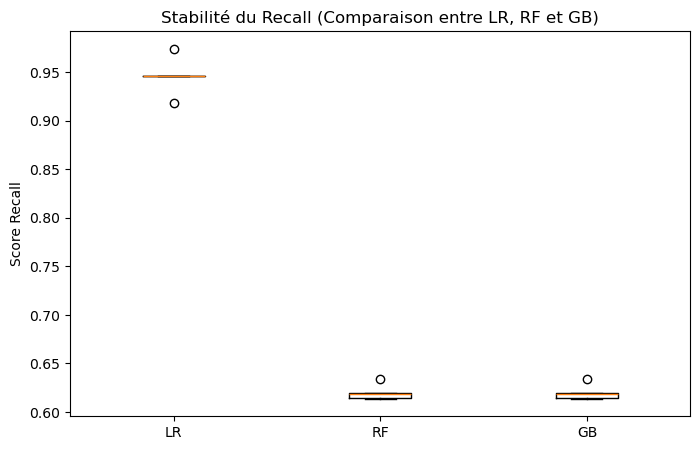

In [4]:
plt.figure(figsize=(8, 5))
plt.boxplot(all_scores_recall, labels=names)
plt.title('Stabilité du Recall (Comparaison entre LR, RF et GB)')
plt.ylabel('Score Recall')

# Sauvegarde du graphique
plt.savefig(
    "stabilite_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Version 2 

In [5]:
# Reproducibility
SEED = 42

# Dataset loading 
data = pd.read_csv("Fraud_dataset.csv")

Y = data["Fraud_Label"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=SEED
)

# Pipeline models 
models = {

    "Logistic Regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=SEED)),
        ("clf", LogisticRegression(
            max_iter=1000,
            C=100.0,                          # Très faible régularisation
            class_weight={0:1, 1:10},        
            random_state=SEED,
            n_jobs=-1
        ))
    ]),
"Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf", RandomForestClassifier(
            n_estimators=600,
            max_depth=18,
            min_samples_leaf=4,
            min_samples_split=8,
            max_features=0.7,
            class_weight={0:1, 1:8},
            bootstrap=True,
            max_samples=0.8,
            random_state=SEED,
            n_jobs=-1,
            oob_score=True
        ))
    ]),

    "Gradient Boosting": ImbPipeline([
        ("clf", GradientBoostingClassifier(
            n_estimators=400,
            learning_rate=0.1,
            max_depth=7,
            min_samples_leaf=1,
            random_state=SEED
        ))
    ])
}


# Validation matrix 

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
all_scores_recall = [] 
names = []
for name, model in models.items():
    cv_results = cross_validate(
        model, 
        X_train, 
        Y_train, 
        cv=cv, 
        scoring=scoring, 
        n_jobs=-1
    )
    
    # on stocke les scores bruts pour le boxplot (ex: les 5 scores du Recall)
    all_scores_recall.append(cv_results["test_recall"])
    names.append(
    "LR" if "Logistic" in name 
    else "RF" if "Random Forest" in name 
    else "GB"
)
    #Results building
    results.append({
        "Model": name,
        "ROC-AUC": cv_results["test_roc_auc"].mean(),
        "Avg Precision": cv_results["test_avg_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "F1": cv_results["test_f1"].mean()
    })
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

                      ROC-AUC  Avg Precision    Recall  Precision        F1
Model                                                                      
Logistic Regression  0.811808       0.808731  1.000000   0.321350  0.486396
Random Forest        0.811213       0.808335  0.834136   0.413536  0.552906
Gradient Boosting    0.807076       0.805866  0.622607   0.980528  0.761591


# Graphique pour comparer les models de Ml

/tmp/ipykernel_7036/2009670916.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_scores_recall, labels=names)


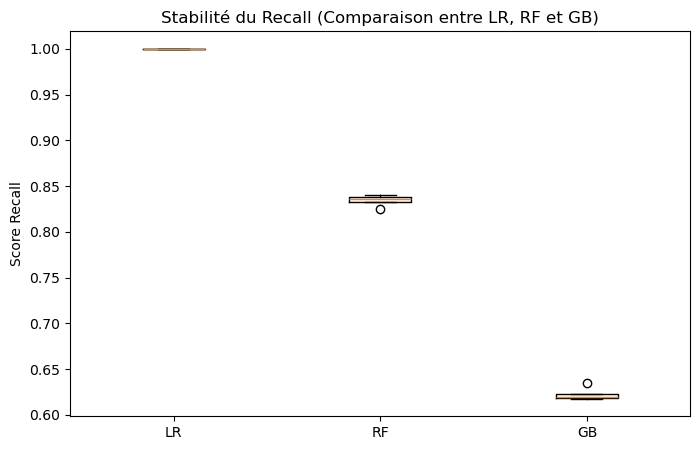

In [6]:
plt.figure(figsize=(8, 5))
plt.boxplot(all_scores_recall, labels=names)
plt.title('Stabilité du Recall (Comparaison entre LR, RF et GB)')
plt.ylabel('Score Recall')

# Sauvegarde du graphique
plt.savefig(
    "stabilite_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
